Load Libraries

In [27]:
import numpy as np
import random
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [28]:
X_train=np.loadtxt("input.csv",delimiter=",")
Y_train=np.loadtxt("labels.csv",delimiter=",")

X_test=np.loadtxt("input_test.csv",delimiter=",")
Y_test=np.loadtxt("labels_test.csv",delimiter=",")

In [29]:
X_train = X_train.reshape(len(X_train), 100, 100, 3)
Y_train = Y_train.reshape(len(Y_train), 1)

X_test = X_test.reshape(len(X_test), 100, 100, 3)
Y_test = Y_test.reshape(len(Y_test), 1)


In [30]:
print("Shape of X_train: ", X_train.shape)
print("Shape of Y_train: ", Y_train.shape)
print("Shape of X_test: ", X_test.shape)
print("Shape of Y_test: ", Y_test.shape)


X_train = X_train/255.0
X_test = X_test/255.0

Shape of X_train:  (2000, 100, 100, 3)
Shape of Y_train:  (2000, 1)
Shape of X_test:  (400, 100, 100, 3)
Shape of Y_test:  (400, 1)


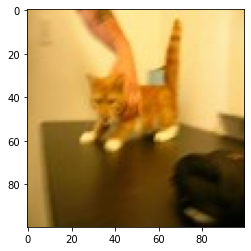

In [31]:
# idx = random.randint(0, len(X_train))
plt.imshow(X_train[1000, :])
# plt.show()

Model

In [34]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation = 'relu', input_shape = (100, 100, 3)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(32, (3,3), activation = 'relu'))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())
model.add(Dense(64, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

compiling

In [35]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [38]:
model.fit(X_train, Y_train, epochs = 5, batch_size = 64)

Epoch 1/5
32/32 [==============================] - 10s 326ms/step - loss: 0.4934 - accuracy: 0.7590
Epoch 2/5
32/32 [==============================] - 10s 328ms/step - loss: 0.4571 - accuracy: 0.7785
Epoch 3/5
32/32 [==============================] - 10s 300ms/step - loss: 0.4130 - accuracy: 0.8045
Epoch 4/5
32/32 [==============================] - 10s 327ms/step - loss: 0.3978 - accuracy: 0.8265
Epoch 5/5
32/32 [==============================] - 10s 307ms/step - loss: 0.3334 - accuracy: 0.8585


In [40]:
model.evaluate(X_test, Y_test)

13/13 [==============================] - 0s 30ms/step - loss: 0.5790 - accuracy: 0.7300


[0.5790491700172424, 0.7300000190734863]

# Making predictions

1/1 [==============================] - 0s 20ms/step
[[False]]
Our model says it is a : dog


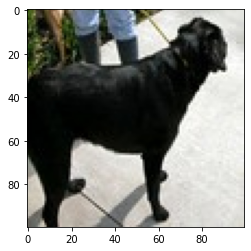

In [53]:
# idx2 = random.randint(0, len(Y_test))
plt.imshow(X_test[100, :])
# plt.show()

y_pred = model.predict(X_test[100, :].reshape(1, 100, 100, 3))
y_pred = y_pred > 0.5
print(y_pred)
if(y_pred == 0):
    pred = 'dog'
else:
    pred = 'cat'
    
print("Our model says it is a :", pred)